# Install required dependencies

In [6]:
!pip install h5netcdf

    sys-platform (=="win32") ; extra == 'angle'
                 ~^


In [7]:
!pip install "numpy<1.24"

    sys-platform (=="win32") ; extra == 'angle'
                 ~^


In [8]:
!pip install --upgrade sunpy

    sys-platform (=="win32") ; extra == 'angle'
                 ~^


# The main code

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

lyra_20120304-000000_lev2_std.fits:   0%|          | 0.00/77.6M [00:00<?, ?B/s]

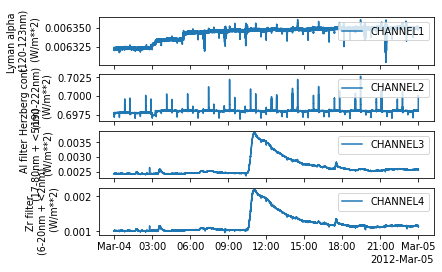

In [2]:
from sunpy.net import Fido, attrs as a
import sunpy.timeseries as ts

# Search for LYRA data
result = Fido.search(a.Time('2012/3/4', '2012/3/6'), a.Instrument.lyra)

# Re-download and overwrite the truncated file
files = Fido.fetch(result[0, 0], overwrite=True)

if len(files) > 0:
    try:
        lyra_ts = ts.TimeSeries(files[0])  # use files[0], not files
        lyra_ts.plot()
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print("No LYRA data found")

In [30]:
pip install --upgrade radiospectra

Note: you may need to restart the kernel to use updated packages.


    sys-platform (=="win32") ; extra == 'angle'
                 ~^


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

ALASKA_20110925_103502_59.fit.gz:   0%|          | 0.00/263k [00:00<?, ?B/s]

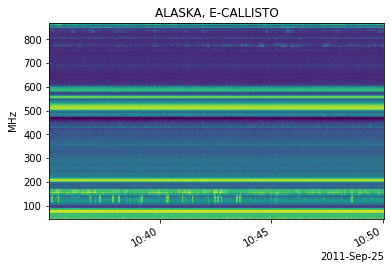

In [33]:
from sunpy.net import Fido, attrs as a
from radiospectra import net
from radiospectra.spectrogram2 import Spectrogram   # ✅ spectrogram2, not spectrogram
import matplotlib.pyplot as plt

result = Fido.search(
    a.Time('2011/09/25 10:30', '2011/09/25 10:45'),
    a.Instrument('eCALLISTO'),
    net.Observatory('ALASKA')
)


files = Fido.fetch(result[0, 0], overwrite=True)

if len(files) > 0:
    try:
        spec = Spectrogram(files[0])               # ✅ plain string works here
        spec.plot()
        plt.show()
    except Exception as e:
        print(f"Error loading spectrogram: {e}")
else:
    print("No e-Callisto data found")